**Нджову Нелиа** *1032239033*
*НКНбд-01-23* *Вариант 9*

In [1]:
import numpy as np
import pandas as pd
import tensorflow_datasets as td
import matplotlib.pyplot as plt
import tensorflow as tf
import keras

1. Загрузите wine_quality из Tensorflow
Datasets и оставьте в наборе данных признаки, принимающие непрерывные
числовые значения, включая указанные в индивидуальном задании
независимую и зависимую переменные. Вычислите матрицу корреляции
признаков и определите пары признаков с наиболее низкой и наиболее
высокой корреляцией.

Я загружаю данные из tensorflow и преобразую набор данных в dataframe

In [2]:

ds = td.load('wine_quality', split = 'train')
df = td.as_dataframe(ds)
df.head()

,features/alcohol,features/chlorides,features/citric acid,features/density,features/fixed acidity,features/free sulfur dioxide,features/pH,features/residual sugar,features/sulphates,features/total sulfur dioxide,features/volatile acidity,quality
0,9.0,0.054,0.34,1.00080,7.6,44.0,3.22,18.35,0.55,197.0,0.32,5
1,12.2,0.063,0.49,0.99110,6.3,35.0,3.38,1.20,0.42,92.0,0.27,6
2,11.2,0.029,0.11,0.99076,5.3,6.0,3.51,1.10,0.48,51.0,0.43,4
3,9.0,0.110,0.27,0.99672,6.6,20.0,3.08,10.70,0.41,103.0,0.41,6
4,12.0,0.035,0.30,0.99016,5.9,57.0,3.09,3.80,0.34,135.0,0.34,6


In [3]:
#удаляю признаки не принимающие непрерывные числовые значения
df.drop(columns='quality', inplace = True)

In [4]:
df.head()

,features/alcohol,features/chlorides,features/citric acid,features/density,features/fixed acidity,features/free sulfur dioxide,features/pH,features/residual sugar,features/sulphates,features/total sulfur dioxide,features/volatile acidity
0,9.0,0.054,0.34,1.00080,7.6,44.0,3.22,18.35,0.55,197.0,0.32
1,12.2,0.063,0.49,0.99110,6.3,35.0,3.38,1.20,0.42,92.0,0.27
2,11.2,0.029,0.11,0.99076,5.3,6.0,3.51,1.10,0.48,51.0,0.43
3,9.0,0.110,0.27,0.99672,6.6,20.0,3.08,10.70,0.41,103.0,0.41
4,12.0,0.035,0.30,0.99016,5.9,57.0,3.09,3.80,0.34,135.0,0.34


Я вычисляю корреляционную матрицу

In [5]:
matrix = df.corr()
matrix

,features/alcohol,features/chlorides,features/citric acid,features/density,features/fixed acidity,features/free sulfur dioxide,features/pH,features/residual sugar,features/sulphates,features/total sulfur dioxide,features/volatile acidity
features/alcohol,1.000000,-0.360189,-0.075729,-0.780138,-0.120881,-0.250104,0.121432,-0.450631,-0.017433,-0.448892,0.067718
features/chlorides,-0.360189,1.000000,0.114364,0.257211,0.023086,0.101392,-0.090439,0.088685,0.016763,0.198910,0.070512
features/citric acid,-0.075729,0.114364,1.000000,0.149503,0.289181,0.094077,-0.163748,0.094212,0.062331,0.121131,-0.149472
features/density,-0.780138,0.257211,0.149503,1.000000,0.265331,0.294210,-0.093592,0.838967,0.074493,0.529881,0.027114
features/fixed acidity,-0.120881,0.023086,0.289181,0.265331,1.000000,-0.049396,-0.425858,0.089021,-0.017143,0.091070,-0.022697
features/free sulfur dioxide,-0.250104,0.101392,0.094077,0.294210,-0.049396,1.000000,-0.000618,0.299098,0.059217,0.615501,-0.097012
features/pH,0.121432,-0.090439,-0.163748,-0.093592,-0.425858,-0.000618,1.000000,-0.194133,0.155951,0.002321,-0.031915
features/residual sugar,-0.450631,0.088685,0.094212,0.838967,0.089021,0.299098,-0.194133,1.000000,-0.026664,0.401439,0.064286
features/sulphates,-0.017433,0.016763,0.062331,0.074493,-0.017143,0.059217,0.155951,-0.026664,1.000000,0.134562,-0.035728
features/total sulfur dioxide,-0.448892,0.198910,0.121131,0.529881,0.091070,0.615501,0.002321,0.401439,0.134562,1.000000,0.089261


Сортировка матрицы и упорядочение пар в соответствии с возрастающей корреляцией

In [6]:
sorted_matrix = matrix.unstack().sort_values()
cor_pairs = sorted_matrix[sorted_matrix < 1.0]

In [7]:
#пара с самой высокой корреляцией
highest = cor_pairs.iloc[-1]
highest_pair = cor_pairs.index[-1]
print(highest_pair,':',highest)

('features/residual sugar', 'features/density') : 0.8389665818874937


In [8]:
#пара с самой низкой корреляцией
lowest = cor_pairs.iloc[0]
lowest_pair = cor_pairs.index[0]
print(lowest_pair,':',lowest)

('features/alcohol', 'features/density') : -0.780137535373538


2. Выполните визуализацию независимой(features/density) и зависимой переменных(features/chlorides), подписывая оси и рисунок.

<Axes: title={'center': 'Столбчатная диаграма признака features/density'}>

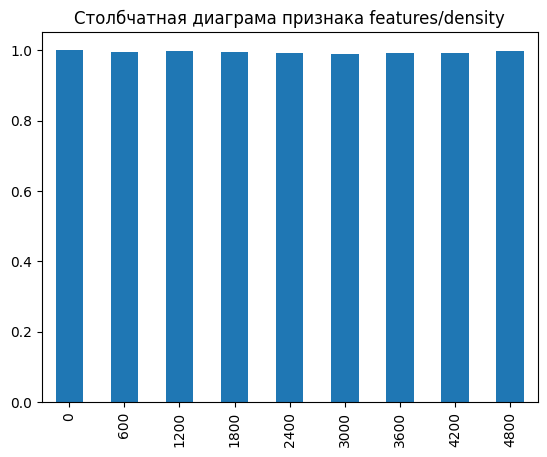

In [9]:
df[::600]['features/density'].plot.bar(title = 'Столбчатная диаграма признака features/density')

Точечная диаграмма показывает взаимосвязь между features/density (независимая переменная) и features/chlorides(зависимая переменная). Точки данных сильно сконцентрированы в определенном регионе, что указывает на то, где сосредоточено большинство наблюдений.

<Axes: title={'center': 'Диаграмма Рассеяния для features/density и features/chloriders'}, xlabel='features/density', ylabel='features/chlorides'>

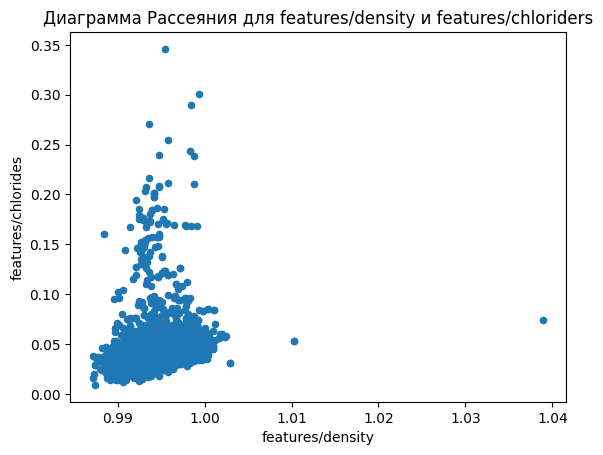

In [10]:
df.plot.scatter('features/density', 'features/chlorides', title = 'Диаграмма Рассеяния для features/density и features/chloriders')

3. Постройте парную линейную регрессию для независимого и зависимого
признаков при помощи точного подхода и при помощи нейронной сети с одним
нейроном. Вычислите и сравните значения показателей качества двух
подходов.

In [11]:
#Класс для простой парной линейной регрессии
class simplelinreg:
  def __init__(self):
    self.a = None
    self.b = None

  def fit(self, x_train, y_train):
    assert x_train.ndim == 1
    assert len(x_train) == len(y_train)
    x_mean = np.mean(x_train)
    y_mean = np.mean(y_train)
    self.a_ = (x_train - x_mean).dot(y_train - y_mean)/  (x_train - x_mean).dot(x_train - x_mean)
    self.b_ = y_mean - self.a_*x_mean
    return self

  def predict(self, x_predict):
    assert x_predict.ndim == 1
    assert self.a_ is not None and self.b_ is not None
    return np.array([self._predict(x) for x in x_predict])

  def _predict(self, x_single):
    return self.a_ * x_single + self.b_

  def __repr__(self):
    return 'simplelinearreg'

Я перемешиваю данные, чтобы улучшить обобщение

In [12]:
shuffled_df = df.sample(frac = 1, random_state = 42)

Разбиваю свои данные на обучающие и тестовые наборы: y_train и y_test являются зависимыми переменными, а x_train и x_test - независимыми переменными

In [13]:
Y = shuffled_df['features/chlorides']
y_train_size = int(0.7*len(Y))
y_train = Y[:y_train_size]
y_test = Y[y_train_size:]
y_train.shape, y_test.shape

((3428,), (1470,))

In [14]:
x_data = shuffled_df.drop(columns = 'features/chlorides')
x_data.head()

,features/alcohol,features/citric acid,features/density,features/fixed acidity,features/free sulfur dioxide,features/pH,features/residual sugar,features/sulphates,features/total sulfur dioxide,features/volatile acidity
4656,10.7,0.28,0.99556,6.8,54.0,3.19,12.600000,0.37,136.0,0.20
3659,8.7,0.99,0.99360,6.6,45.0,3.09,1.200000,0.31,129.0,0.19
907,9.4,0.72,0.99990,8.0,62.0,2.92,17.549999,0.68,233.0,0.66
4352,9.5,0.26,0.99538,6.4,47.0,3.12,8.200000,0.50,182.0,0.24
3271,13.0,0.29,0.99026,7.5,38.0,3.08,4.900000,0.48,113.0,0.38


In [15]:
x_train_size = int(0.7*len(x_data))
x_train = x_data[:x_train_size]
x_test = x_data[x_train_size:]
x_train.shape, x_test.shape

((3428, 10), (1470, 10))

In [16]:
x = x_train['features/density']
y = y_train
x.shape, y.shape

((3428,), (3428,))

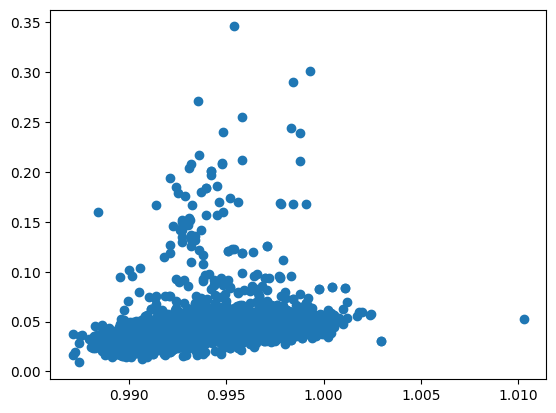

In [17]:
plt.scatter(x,y)

Я создаю объекты этого класса с помощью конструктора и
применяю методы класса к объектам.

In [18]:
reg = simplelinreg()
reg.fit(x,y)

simplelinearreg

In [19]:
reg.a_, reg.b_

(np.float32(2.0515332), np.float32(-1.9934325))

Я рисую линию регрессии на точечном графике

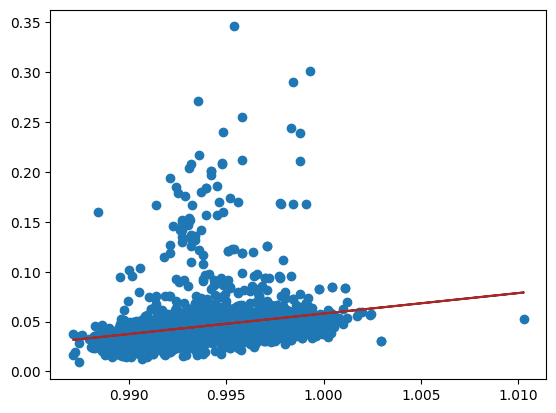

In [20]:
plt.scatter(x,y)
plt.plot(x, reg.predict(x), color = 'brown')

А теперь я добавляю тестовые данные

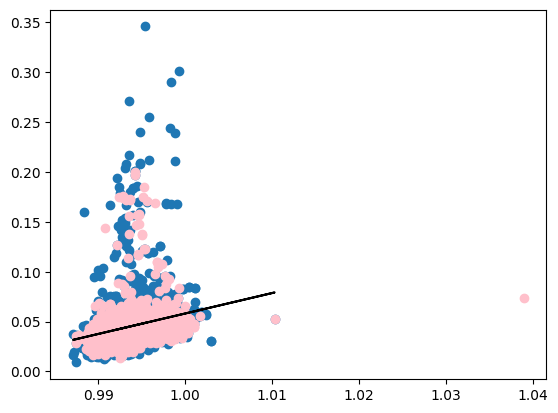

In [21]:
plt.scatter(x,y)
plt.scatter(x_test['features/density'], y_test, color = 'pink')
plt.plot(x, reg.predict(x), color = 'black')

Я получаю прогнозируемые значения для точек тестового набора

In [22]:
y_predict = reg.predict(x_test['features/density'])
y_predict

array([0.04103208, 0.04021144, 0.04189348, ..., 0.03824186, 0.03881621,
       0.04300141], dtype=float32)

Теперь я пишу набор регрессионных программ, используя модель простейшей нейронной сети из одного слоя с одним нейроном.

In [23]:
model = keras.Sequential([keras.layers.Input(shape = (1,)), keras.layers.Dense(1)])

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

После того, как модель построена, я запускаю процесс обучения, вызывая метод compile(). Модель обучается на основе обучающих данных с использованием метода fit(), используя mae в качестве средней абсолютной ошибки

In [25]:
model.compile(loss=keras.losses.mean_absolute_error, optimizer=keras.optimizers.Adam(learning_rate=0.25), metrics=['mean_absolute_error'])

In [26]:
model.fit(x,y, epochs = 150)

Epoch 1/150
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1805 - mean_absolute_error: 0.1805
Epoch 2/150
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0481 - mean_absolute_error: 0.0481
Epoch 3/150
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0857 - mean_absolute_error: 0.0857
Epoch 4/150
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0421 - mean_absolute_error: 0.0421
Epoch 5/150
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0266 - mean_absolute_error: 0.0266
Epoch 6/150
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0393 - mean_absolute_error: 0.0393
Epoch 7/150
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0557 - mean_absolute_error: 0.0557
Epoch 8/150
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0562 - mean_absolute_error: 0.0562
Epoch 9/150
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0330 - mean_absolute_error: 0.0330
Epoch 10/150
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0705 - mean_absolute_error: 0.0705
Epoch 11/150
108/10

Я получаю прогнозируемые значения для точек тестового набора

In [27]:
y_predict2 = model.predict(x_test['features/density'])
y_predict2[:5]

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[0.04242462],
       [0.0420869 ],
       [0.04277927],
       [0.0469085 ],
       [0.04164779]], dtype=float32)

In [28]:
mse = np.sum((y_predict - y_test)**2) / len(y_test)
r2 = 1 - mse/np.var(y_test)
r2


np.float32(0.05139208)

In [29]:
y_predict2.shape

(1470, 1)

In [30]:
y_predict2_flat = y_predict2.flatten()
y_predict2_flat.shape

(1470,)

In [31]:
mse = np.sum((y_predict2_flat - y_test)**2) / len(y_test)
r2 = 1 - mse/np.var(y_test)
r2

np.float32(0.0431484)

Линейная регрессия R² = 0.051, нейронная сеть R² = 0.043. Оба значения близки к нулю, что указывает на слабую предсказательную способность модели. Линейная регрессия показывает лучше результат, чем нейронная сеть


4. Постройте диаграмму рассеяния для независимого и зависимого признаков и
изобразите линии двух построенных парных регрессий, подписывая оси и
рисунок и создавая легенду

/tmp/ipython-input-3435404574.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


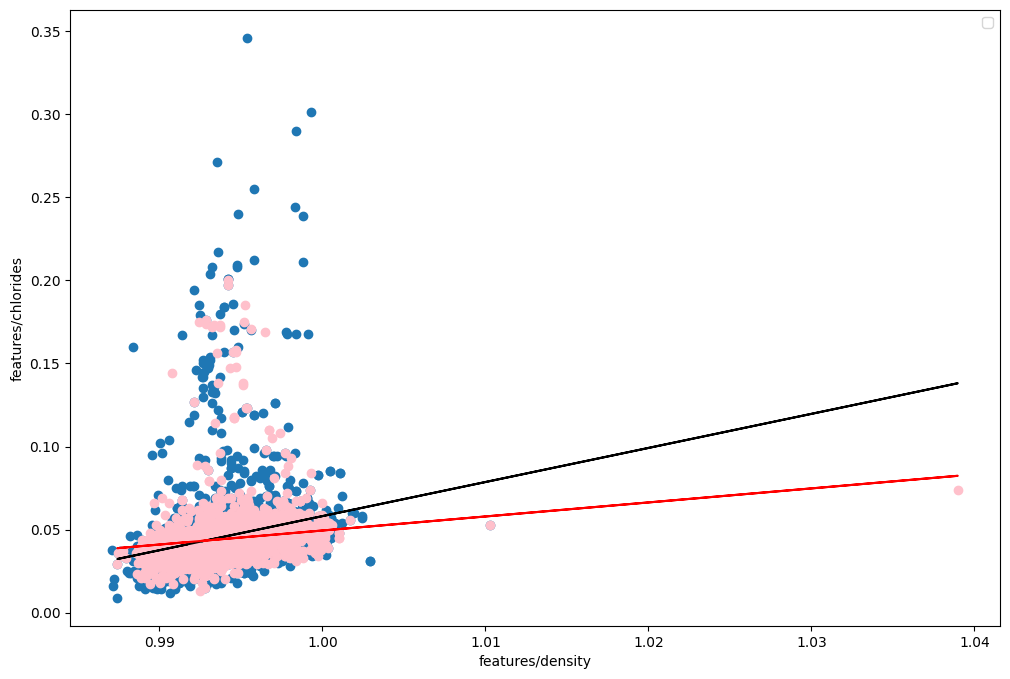

In [32]:
plt.figure(figsize=(12,8))
plt.scatter(x,y)
plt.scatter(x_test['features/density'], y_test, color = 'pink')
plt.plot(x_test['features/density'], y_predict, color = 'black')
plt.plot(x_test['features/density'], y_predict2, color = 'red')
plt.xlabel('features/density')
plt.ylabel('features/chlorides')
plt.legend()

5. Разбейте набор признаков на обучающую и контрольную выборки. Создайте и
адаптируйте нормализующий слой Tensorflow для всех признаков набора
данных (за исключением зависимого признака).

Я создаю и адаптирую слой нормализации. Нормализация масштабирует входные характеристики до стандартного диапазона или распределения.

In [33]:
normalizer = keras.layers.Normalization()

In [34]:
normalizer.adapt(x_train.to_numpy())

In [35]:
normalizer.adapt(x_test.to_numpy())

Я вычисляю средние значения и отклонения

In [36]:
print(normalizer.mean.numpy())
print(normalizer.variance.numpy())

[[ 10.521286     0.33761224   0.99404573   6.824898    35.183334
    3.1925986    6.4390817    0.4919864  139.72755      0.27830952]]
[[1.5143901e+00 1.4442530e-02 9.7339507e-06 7.2665900e-01 2.5553833e+02
  2.2716103e-02 2.6873800e+01 1.3826394e-02 1.7930052e+03 9.6680773e-03]]


6. Используя созданный нормализующий слой, постройте регресоры на базе
следующих моделей множественной регрессии:
- линейной регрессии
- гребневой регрессии (L2)
- лассо регрессии (L1)

Я создаю модель, основанную на линейной регрессии с нормализацией всех функций, и компилирую ее

In [37]:
#линейной регрессии
linear_model = keras.Sequential([normalizer, keras.layers.Dense(units=1)])

In [38]:
linear_model.compile(optimizer=tf.optimizers.Adam(learning_rate=0.001), loss='mean_absolute_error')

In [39]:
#Обучим модель
history_linear = linear_model.fit(x_train, y_train, epochs=80, validation_split = 0.2)

Epoch 1/80
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.1647 - val_loss: 0.9840
Epoch 2/80
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9391 - val_loss: 0.8014
Epoch 3/80
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7730 - val_loss: 0.6657
Epoch 4/80
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6408 - val_loss: 0.5538
Epoch 5/80
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5144 - val_loss: 0.4531
Epoch 6/80
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4125 - val_loss: 0.3584
Epoch 7/80
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3108 - val_loss: 0.2674
Epoch 8/80
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2374 - val_loss: 0.1822
Epoch 9/80
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1557 - val_loss: 0.1067
Epoch 10/80
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0891 - val_loss: 0.0464
Epoch 11/80
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0374 - val_loss: 0.0208
Epoch 12/80
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0219 - val_lo

Ошибка уменьшается, а это значит, что нейронная сеть обучается.

Я создаю модель, основанную на регрессии лассо с нормализацией всех функций и регуляризацией L1, и компилирую ее

In [40]:
#лассо регрессии (L1)
l1_model = keras.Sequential([normalizer, keras.layers.Dense(units=1, kernel_regularizer=keras.regularizers.L1(l1=0.01))])

In [41]:
l1_model.compile(optimizer=tf.optimizers.Adam(learning_rate=0.001), loss='mean_absolute_error')

In [42]:
#Обучим модель
history_l1 = l1_model.fit(x_train, y_train, epochs=100, validation_split = 0.2)

Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.2183 - val_loss: 1.0108
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9971 - val_loss: 0.8189
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7890 - val_loss: 0.6616
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6676 - val_loss: 0.5322
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5090 - val_loss: 0.4175
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3919 - val_loss: 0.3088
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2893 - val_loss: 0.2075
Epoch 8/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1953 - val_loss: 0.1195
Epoch 9/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1048 - val_loss: 0.0578
Epoch 10/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0507 - val_loss: 0.0309
Epoch 11/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0308 - val_loss: 0.0245
Epoch 12/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0



Я создаю модель, основанную на регрессии гребня с нормализацией всех функций и регуляризацией L2, и компилирую ее

In [43]:
#гребневой регрессии (L2)
l2_model = keras.Sequential([normalizer, keras.layers.Dense(units=1, kernel_regularizer=keras.regularizers.L2(l2=0.01))])

In [44]:
l2_model.compile(optimizer=tf.optimizers.Adam(learning_rate=0.001), loss='mean_absolute_error')

In [45]:
history_l2 = l2_model.fit(x_train, y_train, epochs=100, validation_split = 0.2)

Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.4337 - val_loss: 1.1752
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1608 - val_loss: 0.9206
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8858 - val_loss: 0.6894
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6460 - val_loss: 0.4913
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4486 - val_loss: 0.3382
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2968 - val_loss: 0.2228
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1919 - val_loss: 0.1320
Epoch 8/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1077 - val_loss: 0.0638
Epoch 9/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0515 - val_loss: 0.0241
Epoch 10/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0231 - val_loss: 0.0188
Epoch 11/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0201 - val_loss: 0.0170
Epoch 12/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0

7. Определите на контрольной выборке модель множественной регрессии с
наиболее высоким качеством по показателю, указанному в индивидуальном
задании - MAE, среди построенных моделей.

Используя контрольную выборку с нормализованным зависимым показателем, я определяю наиболее успешную модель с точки зрения качества регрессии MAE

In [46]:
y_pred_linear = linear_model.predict(x_test).reshape(-1)
mae_linear = np.sum(np.absolute(y_pred_linear - y_test))/len(y_test)
mae_linear

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


np.float32(0.009348004)

In [47]:
y_pred_l1 = l1_model.predict(x_test).reshape(-1)
mae_l1 = np.sum(np.absolute(y_pred_l1 - y_test))/len(y_test)
mae_l1

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


np.float32(0.009203832)

In [48]:
y_pred_l2 = l2_model.predict(x_test).reshape(-1)
mae_l2 = np.sum(np.absolute(y_pred_l2 - y_test))/len(y_test)
mae_l2

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


np.float32(0.009531543)

В результате, самой качественной моделью множественной регрессии является модель лассо регрессии.

8. Для лучшего регрессора визуализируйте кривые обучения (в зависимости от
эпохи обучения).

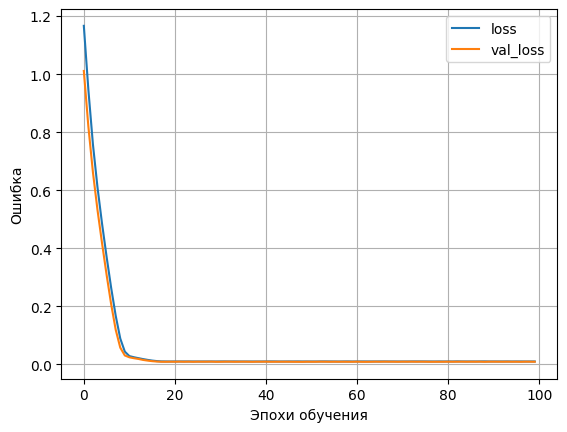

In [50]:
def plot_loss(history):
  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='val_loss')
  plt.xlabel('Эпохи обучения')
  plt.ylabel('Ошибка')
  plt.legend()
  plt.grid(True)

plot_loss(history_l1)